# You have been hired by the Kenya Metrological department as a Data scientist. The ICT manager has tasked you with the job of analyzing weather data for major cities in Kenya. You are required to gather, process, and store the data using various data formats and tools available in Pandas.

## Tasks

- Use the OpenWeatherMap API to fetch current weather data for the following Kenyan cities: Nairobi, Mombasa, Kisumu, Nakuru, and Eldoret.
- Store the collected data in a Pandas DataFrame.
- Save the DataFrame to a CSV file.
-  a simple analysis to find the city with the highest temperature.
- Create a report summarizing the weather conditions for each city.

In [1]:
import pandas as pd
import numpy as np

In [2]:
import requests
import pandas as pd

# API key and endpoint
api_key = 'f4aaacf29976bba0a688d364c5e511c3'
base_url = 'https://api.openweathermap.org/data/2.5/weather'

# Kenyan cities with coordinates (lat, lon)
cities = {
    'Nairobi': (1.2921, 36.8219),
    'Mombasa': (-4.0435, 39.6682),
    'Kisumu': (-0.0917, 34.7680),
    'Nakuru': (-0.3167, 36.0833),
    'Eldoret': (0.3167, 35.2833)
}

# List to store city weather data
weather_list = []

# Fetch weather data for each city
for city, (lat, lon) in cities.items():
    params = {
        'lat': lat,
        'lon': lon,
        'units': 'metric',
        'appid': api_key
    }
    response = requests.get(base_url, params=params)
    if response.status_code == 200:
        data = response.json()
        city_weather = {
            'City': city,
            'Temperature (°C)': data['main']['temp'],
            'Humidity (%)': data['main']['humidity'],
            'Pressure (hPa)': data['main']['pressure'],
            'Weather': data['weather'][0]['description'],
            'Wind Speed (m/s)': data['wind']['speed'],
            'Rain (mm last 1h)': data['rain']['1h'] if 'rain' in data and '1h' in data['rain'] else 0
        }
        weather_list.append(city_weather)
    else:
        print(f'Failed to get data for {city}')

# Create DataFrame
weather_df = pd.DataFrame(weather_list)

# Save DataFrame to CSV
weather_df.to_csv('kenya_weather.csv', index=False)

# Report: Summary of all cities
print("Weather Summary Report for Major Kenyan Cities:")
print(weather_df)

Weather Summary Report for Major Kenyan Cities:
      City  Temperature (°C)  Humidity (%)  Pressure (hPa)          Weather  \
0  Nairobi             27.74            46            1012  overcast clouds   
1  Mombasa             32.22            62            1011       light rain   
2   Kisumu             26.24            52            1011  overcast clouds   
3   Nakuru             24.11            51            1013       light rain   
4  Eldoret             23.55            40            1012       light rain   

   Wind Speed (m/s)  Rain (mm last 1h)  
0              3.82               0.00  
1              3.09               0.13  
2              2.65               0.00  
3              1.26               0.35  
4              2.01               0.12  


In [3]:
max_temp_row = weather_df.loc[weather_df['Temperature (°C)'].idxmax()]
print(f"City with highest temperature: {max_temp_row['City']} ({max_temp_row['Temperature (°C)']}°C)\n")
print("Weather Summary: " + str(weather_df.shape[0]) + "cities")
weather_df.sort_values(by='Rain (mm last 1h)', ascending=False)


City with highest temperature: Mombasa (32.22°C)

Weather Summary: 5cities


,City,Temperature (°C),Humidity (%),Pressure (hPa),Weather,Wind Speed (m/s),Rain (mm last 1h)
3,Nakuru,24.11,51,1013,light rain,1.26,0.35
1,Mombasa,32.22,62,1011,light rain,3.09,0.13
4,Eldoret,23.55,40,1012,light rain,2.01,0.12
0,Nairobi,27.74,46,1012,overcast clouds,3.82,0.00
2,Kisumu,26.24,52,1011,overcast clouds,2.65,0.00


In [4]:
#analyzing and giving conclusion summarry describing the rains, temperature and humidity
def analyze_weather_data(df):
    summary = "Weather Analysis Summary:\n"
    
    # Overall weather conditions
    avg_temp = df['Temperature (°C)'].mean()
    avg_humidity = df['Humidity (%)'].mean()
    summary += f"- Average Temperature: {avg_temp:.2f}°C\n"
    summary += f"- Average Humidity: {avg_humidity:.2f}%\n"
    
    # Flood alert analysis
    flood_risk_cities = df[df['Rain (mm last 1h)'] >= 20]
    if not flood_risk_cities.empty:
        summary += "- Cities at Flood Risk:\n"
        for _, row in flood_risk_cities.iterrows():
            summary += f"  - {row['City']} with {row['Rain (mm last 1h)']} mm of rain\n"
    else:
        summary += "- No cities currently at high flood risk.\n"
    
    # Actionable insights
    if not flood_risk_cities.empty:
        summary += "Recommended Actions:\n"
        summary += "- Residents in high-risk cities should stay informed through local news and authorities.\n"
        summary += "- Prepare emergency kits and have evacuation plans ready.\n"
        summary += "- Avoid traveling to or through high-risk areas during heavy rainfall.\n"
    
    return summary

analysis_summary = analyze_weather_data(weather_df)
print(analysis_summary)

Weather Analysis Summary:
- Average Temperature: 26.77°C
- Average Humidity: 50.20%
- No cities currently at high flood risk.



In [5]:
#predict the possibility of heavy rains in the next 24 hours based on current weather conditions
def predict_heavy_rains(df):
    predictions = "Heavy Rain Prediction for the Next 24 Hours:\n"
    
    for _, row in df.iterrows():
        city = row['City']
        rain = row['Rain (mm last 1h)']
        humidity = row['Humidity (%)']
        temp = row['Temperature (°C)']
        
        # Simple heuristic for prediction
        if rain > 10 and humidity > 80 and temp < 25:
            predictions += f"- {city}: High chance of heavy rains.\n"
        elif rain > 5 and humidity > 70:
            predictions += f"- {city}: Moderate chance of heavy rains.\n"
        else:
            predictions += f"- {city}: Low chance of heavy rains.\n"
    
    return predictions
rain_predictions = predict_heavy_rains(weather_df)
print(rain_predictions)

Heavy Rain Prediction for the Next 24 Hours:
- Nairobi: Low chance of heavy rains.
- Mombasa: Low chance of heavy rains.
- Kisumu: Low chance of heavy rains.
- Nakuru: Low chance of heavy rains.
- Eldoret: Low chance of heavy rains.



In [6]:
#check weather conditions in the next 4 days from the open weather Api
forecast_url = 'https://api.openweathermap.org/data/2.5/forecast'
forecast_list = []
for city, (lat, lon) in cities.items():
    params = {
        'lat': lat,
        'lon': lon,
        'units': 'metric',
        'appid': api_key
    }
    response = requests.get(forecast_url, params=params)
    if response.status_code == 200:
        data = response.json()
        for forecast in data['list']:
            forecast_entry = {
                'City': city,
                'DateTime': forecast['dt_txt'],
                'Temperature (°C)': forecast['main']['temp'],
                'Humidity (%)': forecast['main']['humidity'],
                'Pressure (hPa)': forecast['main']['pressure'],
                'Weather': forecast['weather'][0]['description'],
                'Wind Speed (m/s)': forecast['wind']['speed'],
                'Rain (mm last 3h)': forecast['rain']['3h'] if 'rain' in forecast and '3h' in forecast['rain'] else 0
            }
            forecast_list.append(forecast_entry)
    else:
        print(f'Failed to get forecast data for {city}')
forecast_df = pd.DataFrame(forecast_list)
forecast_df.to_csv('kenya_weather_forecast.csv', index=False)
print("Weather Forecast for the Next 4 Days:")
print(forecast_df)

Weather Forecast for the Next 4 Days:
        City             DateTime  Temperature (°C)  Humidity (%)  \
0    Nairobi  2026-03-18 09:00:00             28.95            41   
1    Nairobi  2026-03-18 12:00:00             28.99            40   
2    Nairobi  2026-03-18 15:00:00             25.85            57   
3    Nairobi  2026-03-18 18:00:00             21.97            77   
4    Nairobi  2026-03-18 21:00:00             21.74            77   
..       ...                  ...               ...           ...   
195  Eldoret  2026-03-22 18:00:00             14.81            91   
196  Eldoret  2026-03-22 21:00:00             13.88            94   
197  Eldoret  2026-03-23 00:00:00             13.51            94   
198  Eldoret  2026-03-23 03:00:00             13.23            95   
199  Eldoret  2026-03-23 06:00:00             16.52            78   

     Pressure (hPa)          Weather  Wind Speed (m/s)  Rain (mm last 3h)  
0              1011  overcast clouds              4.29   

Text(0.5, 1.0, 'Current Temperature in Major Kenyan Cities')

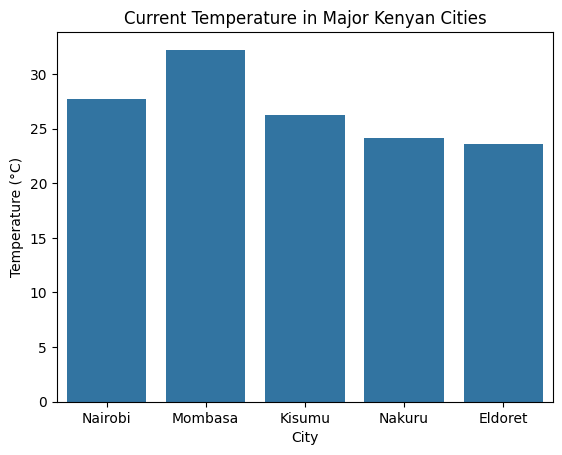

In [7]:
#visualization of the weather data using matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

ggplot = sns.barplot(x='City', y='Temperature (°C)', data=weather_df)
ggplot.set_title('Current Temperature in Major Kenyan Cities')
# 

Text(0.5, 1.0, 'Current Humidity in Major Kenyan Cities')

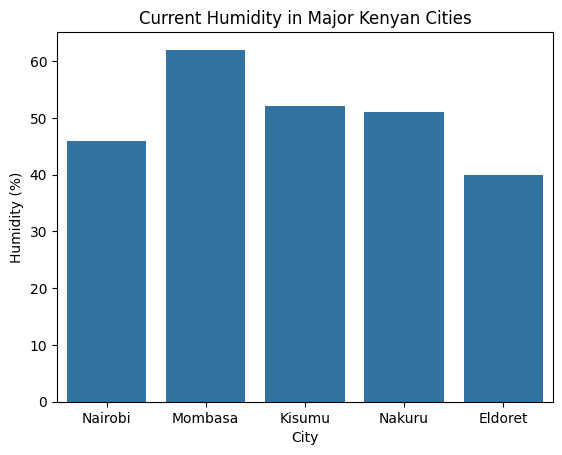

In [8]:
ggplot = sns.barplot(x='City', y='Humidity (%)', data=weather_df)
ggplot.set_title('Current Humidity in Major Kenyan Cities')

In [9]:
#based on the expected rains from the forecast data possibility of heavy rains in the next 24 hours
def predict_heavy_rains_forecast(df):
    predictions = "Heavy Rain Prediction for the Next 24 Hours Based on Forecast:\n"
    
    for city in df['City'].unique():
        city_forecast = df[df['City'] == city]
        max_rain = city_forecast['Rain (mm last 3h)'].max()
        avg_humidity = city_forecast['Humidity (%)'].mean()
        avg_temp = city_forecast['Temperature (°C)'].mean()
        
        if max_rain > 20 and avg_humidity > 80 and avg_temp < 25:
            predictions += f"- {city}: High chance of heavy rains.\n"
        elif max_rain > 10 and avg_humidity > 70:
            predictions += f"- {city}: Moderate chance of heavy rains.\n"
        else:
            predictions += f"- {city}: Low chance of heavy rains.\n"
    
    return predictions
forecast_rain_predictions = predict_heavy_rains_forecast(forecast_df)
print(forecast_rain_predictions)

#chances of experiencing floods in the next 24 hours based on the forecast data
def predict_flood_risk_forecast(df):
    predictions = "Flood Risk Prediction for the Next 24 Hours Based on Forecast:\n"
    
    for city in df['City'].unique():
        city_forecast = df[df['City'] == city]
        max_rain = city_forecast['Rain (mm last 3h)'].max()
        
        if max_rain > 30:
            predictions += f"- {city}: High flood risk.\n"
        elif max_rain > 15:
            predictions += f"- {city}: Moderate flood risk.\n"
        else:
            predictions += f"- {city}: Low flood risk.\n"
    
    return predictions
flood_risk_predictions = predict_flood_risk_forecast(forecast_df)
print(flood_risk_predictions)

Heavy Rain Prediction for the Next 24 Hours Based on Forecast:
- Nairobi: Low chance of heavy rains.
- Mombasa: Low chance of heavy rains.
- Kisumu: Moderate chance of heavy rains.
- Nakuru: Low chance of heavy rains.
- Eldoret: Low chance of heavy rains.

Flood Risk Prediction for the Next 24 Hours Based on Forecast:
- Nairobi: Low flood risk.
- Mombasa: Low flood risk.
- Kisumu: Low flood risk.
- Nakuru: Low flood risk.
- Eldoret: Low flood risk.



In [10]:
#expected rains in the afternoon
def predict_afternoon_rains(df):
    predictions = "Afternoon Rain Prediction for the Next 4 Days:\n"
    
    for city in df['City'].unique():
        city_forecast = df[df['City'] == city]
        afternoon_forecast = city_forecast[city_forecast['DateTime'].str.contains('15:00:00')]
        
        if not afternoon_forecast.empty:
            max_rain = afternoon_forecast['Rain (mm last 3h)'].max()
            if max_rain > 20:
                predictions += f"- {city}: High chance of rain in the afternoon.\n"
            elif max_rain > 10:
                predictions += f"- {city}: Moderate chance of rain in the afternoon.\n"
            else:
                predictions += f"- {city}: Low chance of rain in the afternoon.\n"
        else:
            predictions += f"- {city}: No forecast data for the afternoon.\n"
    
    return predictions
afternoon_rain_predictions = predict_afternoon_rains(forecast_df)
print(afternoon_rain_predictions)

Afternoon Rain Prediction for the Next 4 Days:
- Nairobi: Low chance of rain in the afternoon.
- Mombasa: Low chance of rain in the afternoon.
- Kisumu: Moderate chance of rain in the afternoon.
- Nakuru: Low chance of rain in the afternoon.
- Eldoret: Low chance of rain in the afternoon.



In [11]:
#chances or raining and flooding in Nairobi in the afternoon

def predict_afternoon_rains_and_floods(df):
    predictions = "Afternoon Rain and Flood Risk Prediction for the Next 4 Days:\n"
    
    for city in df['City'].unique():
        city_forecast = df[df['City'] == city]
        afternoon_forecast = city_forecast[city_forecast['DateTime'].str.contains('15:00:00')]
        
        if not afternoon_forecast.empty:
            max_rain = afternoon_forecast['Rain (mm last 3h)'].max()
            if max_rain > 20:
                predictions += f"- {city}: High chance of rain and flood risk in the afternoon.\n"
            elif max_rain > 10:
                predictions += f"- {city}: Moderate chance of rain and flood risk in the afternoon.\n"
            else:
                predictions += f"- {city}: Low chance of rain and flood risk in the afternoon.\n"
        else:
            predictions += f"- {city}: No forecast data for the afternoon.\n"
    
    return predictions
afternoon_prediction = predict_afternoon_rains_and_floods(forecast_df)
print(afternoon_prediction)

Afternoon Rain and Flood Risk Prediction for the Next 4 Days:
- Nairobi: Low chance of rain and flood risk in the afternoon.
- Mombasa: Low chance of rain and flood risk in the afternoon.
- Kisumu: Moderate chance of rain and flood risk in the afternoon.
- Nakuru: Low chance of rain and flood risk in the afternoon.
- Eldoret: Low chance of rain and flood risk in the afternoon.



In [12]:
#Niarobi afternoon rain and flood risk prediction
nairobi_forecast = forecast_df[forecast_df['City'] == 'Nairobi']
nairobi_afternoon_forecast = nairobi_forecast[nairobi_forecast['DateTime'].str.contains('15:00:00')]
if not nairobi_afternoon_forecast.empty:
    max_rain = nairobi_afternoon_forecast['Rain (mm last 1h)'].max()
    if max_rain > 20:
        print("Nairobi: High chance of rain and flood risk in the afternoon.")
    elif max_rain > 10:
        print("Nairobi: Moderate chance of rain and flood risk in the afternoon.")
    else:
        print("Nairobi: Low chance of rain and flood risk in the afternoon.")

KeyError: 'Rain (mm last 1h)'